# <center>Data ingestion
</center>

In [4]:
import pandas as pd

columns = [
    "index",
    "Lever position (Lp)",
    "Ship speed (V) [knots]",
    "Gas Turbine shaft torque (GTT) [kN·m]",
    "Gas Turbine revolutions (GTn) [rpm]",
    "Gas Generator revolutions (GGn) [rpm]",
    "Starboard Propeller Torque (Ts) [kN·m]",
    "Port Propeller Torque (Tp) [kN·m]",
    "HP Turbine exit temperature (T48) [°C]",
    "Compressor inlet air temperature (T1) [°C]",
    "Compressor outlet air temperature (T2) [°C]",
    "HP Turbine exit pressure (P48) [bar]",
    "Compressor inlet air pressure (P1) [bar]",
    "Compressor outlet air pressure (P2) [bar]",
    "Exhaust gas pressure (Pexh) [bar]",
    "Turbine Injection Control (TIC) [%]",
    "Fuel flow (mf) [kg/s]",
    "Compressor decay coefficient",
    "Turbine decay coefficient"
]

df = pd.read_csv("capstone/code/data/data.txt", 
                 sep=r'\s+', 
                 header=None)

df.index = df.index + 1
df.reset_index(inplace=True)
df.columns = columns

# Save to CSV
df.to_csv("capstone/code/data/turbine_data.csv", index=False)


print("Converted Sensor logs txt (data.txt) --> csv (turbine_data.csv)\n")
print("First 5 rows of Unprocessed data")
print(df.head())



FileNotFoundError: [Errno 2] No such file or directory: 'capstone/code/data/data.txt'

# <center> Data Cleaning </center>

#### Handle nulls, outliers, smoothing

In [16]:
# Keep first column as integer
df['index'] = df['index'].astype(int)

# Select all other numeric columns exclude index
numeric_cols = df.columns[1:] 

# Fill numeric nulls with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Outlier using (IQR Method)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

# Smoothing values
df[numeric_cols] = df[numeric_cols].rolling(window=3, min_periods=1).mean()

# Round numbers to 2 decimals
df[numeric_cols] = df[numeric_cols].round(2)

print("Cleaned Data")
print(df.head())

Cleaned Data
   index  Lever position (Lp)  Ship speed (V) [knots]  \
0      1                 1.14                    3.00   
1      1                 1.26                    3.38   
2      2                 1.38                    3.75   
3      3                 1.76                    4.92   
4      4                 2.35                    6.67   

   Gas Turbine shaft torque (GTT) [kN·m]  Gas Turbine revolutions (GTn) [rpm]  \
0                                 289.96                              1349.49   
1                                1123.74                              1352.82   
2                                1763.03                              1355.56   
3                                3761.50                              1369.11   
4                                6458.38                              1408.96   

   Gas Generator revolutions (GGn) [rpm]  \
0                                6677.38   
1                                6696.26   
2                        

#### Derived Features : Temp_ratio_T48_T2, Temp_ratio_T1_P1, Torque_diff, RPM_ratio_GTn_GGn, Fuel_per_RPM, Total_Prop_Torque

In [19]:
# Temperature-Pressure Ratios
df['Temp_ratio_T48_T2'] = (df['HP Turbine exit temperature (T48) [°C]'] / 
                           df['Compressor outlet air temperature (T2) [°C]']).round(2)
df['Temp_ratio_T1_P1'] = (df['Compressor inlet air temperature (T1) [°C]'] / 
                          df['Compressor inlet air pressure (P1) [bar]']).round(2)

# Torque Differentials
df['Torque_diff'] = (df['Starboard Propeller Torque (Ts) [kN·m]'] - 
                     df['Port Propeller Torque (Tp) [kN·m]']).round(2)

# Efficiency Indicators
df['RPM_ratio_GTn_GGn'] = (df['Gas Turbine revolutions (GTn) [rpm]'] / 
                           df['Gas Generator revolutions (GGn) [rpm]']).round(2)
df['Fuel_per_RPM'] = (df['Fuel flow (mf) [kg/s]'] / df['Gas Turbine revolutions (GTn) [rpm]']).round(5)

# Total Propeller Torque
df['Total_Prop_Torque'] = (df['Starboard Propeller Torque (Ts) [kN·m]'] +
                            df['Port Propeller Torque (Tp) [kN·m]']).round(2)


pd.set_option('display.max_columns', None)
print("Cleaned Data with Derived Features")
print(df.head())


Cleaned Data with Derived Features
   index  Lever position (Lp)  Ship speed (V) [knots]  \
0      1                 1.14                    3.00   
1      1                 1.26                    3.38   
2      2                 1.38                    3.75   
3      3                 1.76                    4.92   
4      4                 2.35                    6.67   

   Gas Turbine shaft torque (GTT) [kN·m]  Gas Turbine revolutions (GTn) [rpm]  \
0                                 289.96                              1349.49   
1                                1123.74                              1352.82   
2                                1763.03                              1355.56   
3                                3761.50                              1369.11   
4                                6458.38                              1408.96   

   Gas Generator revolutions (GGn) [rpm]  \
0                                6677.38   
1                                6696.26   
2  

#### EDA (Exploratory Data Analysis)

- Summary statistics
- Null check
- Correlation heatmap
- Histograms
- Boxplots
- Pair plots


In [25]:
print("Summary Statistics ")
print(df.describe())

Summary Statistics 
         index  Lever position (Lp)  Ship speed (V) [knots]  \
count 11934.00             11934.00                11934.00   
mean   5966.50                 5.16                   15.00   
std    3445.19                 1.27                    3.75   
min       1.00                 1.14                    3.00   
25%    2983.25                 4.14                   12.00   
50%    5966.50                 5.15                   15.00   
75%    8949.75                 6.16                   18.00   
max   11933.00                 6.86                   20.00   

       Gas Turbine shaft torque (GTT) [kN·m]  \
count                               11934.00   
mean                                27234.93   
std                                 10406.79   
min                                   289.96   
25%                                 16075.67   
50%                                 26616.72   
75%                                 37564.38   
max                         

In [26]:
print("\nTotal Null Values ")
print(df.isnull().sum())



Total Null Values 
index                                          0
Lever position (Lp)                            0
Ship speed (V) [knots]                         0
Gas Turbine shaft torque (GTT) [kN·m]          0
Gas Turbine revolutions (GTn) [rpm]            0
Gas Generator revolutions (GGn) [rpm]          0
Starboard Propeller Torque (Ts) [kN·m]         0
Port Propeller Torque (Tp) [kN·m]              0
HP Turbine exit temperature (T48) [°C]         0
Compressor inlet air temperature (T1) [°C]     0
Compressor outlet air temperature (T2) [°C]    0
HP Turbine exit pressure (P48) [bar]           0
Compressor inlet air pressure (P1) [bar]       0
Compressor outlet air pressure (P2) [bar]      0
Exhaust gas pressure (Pexh) [bar]              0
Turbine Injection Control (TIC) [%]            0
Fuel flow (mf) [kg/s]                          0
Compressor decay coefficient                   0
Turbine decay coefficient                      0
Temp_ratio_T48_T2                              0


In [38]:
numeric_cols = df.columns[1:]
corr_matrix = df[numeric_cols].corr()
print("\nCorrelation Matrix ")
print(corr_matrix)


Correlation Matrix 
                                             Lever position (Lp)  \
Lever position (Lp)                                         1.00   
Ship speed (V) [knots]                                      1.00   
Gas Turbine shaft torque (GTT) [kN·m]                       0.95   
Gas Turbine revolutions (GTn) [rpm]                         0.96   
Gas Generator revolutions (GGn) [rpm]                       0.99   
Starboard Propeller Torque (Ts) [kN·m]                      0.95   
Port Propeller Torque (Tp) [kN·m]                           0.95   
HP Turbine exit temperature (T48) [°C]                      0.95   
Compressor inlet air temperature (T1) [°C]                   NaN   
Compressor outlet air temperature (T2) [°C]                 0.98   
HP Turbine exit pressure (P48) [bar]                        0.95   
Compressor inlet air pressure (P1) [bar]                     NaN   
Compressor outlet air pressure (P2) [bar]                   0.96   
Exhaust gas pressure (Pexh)

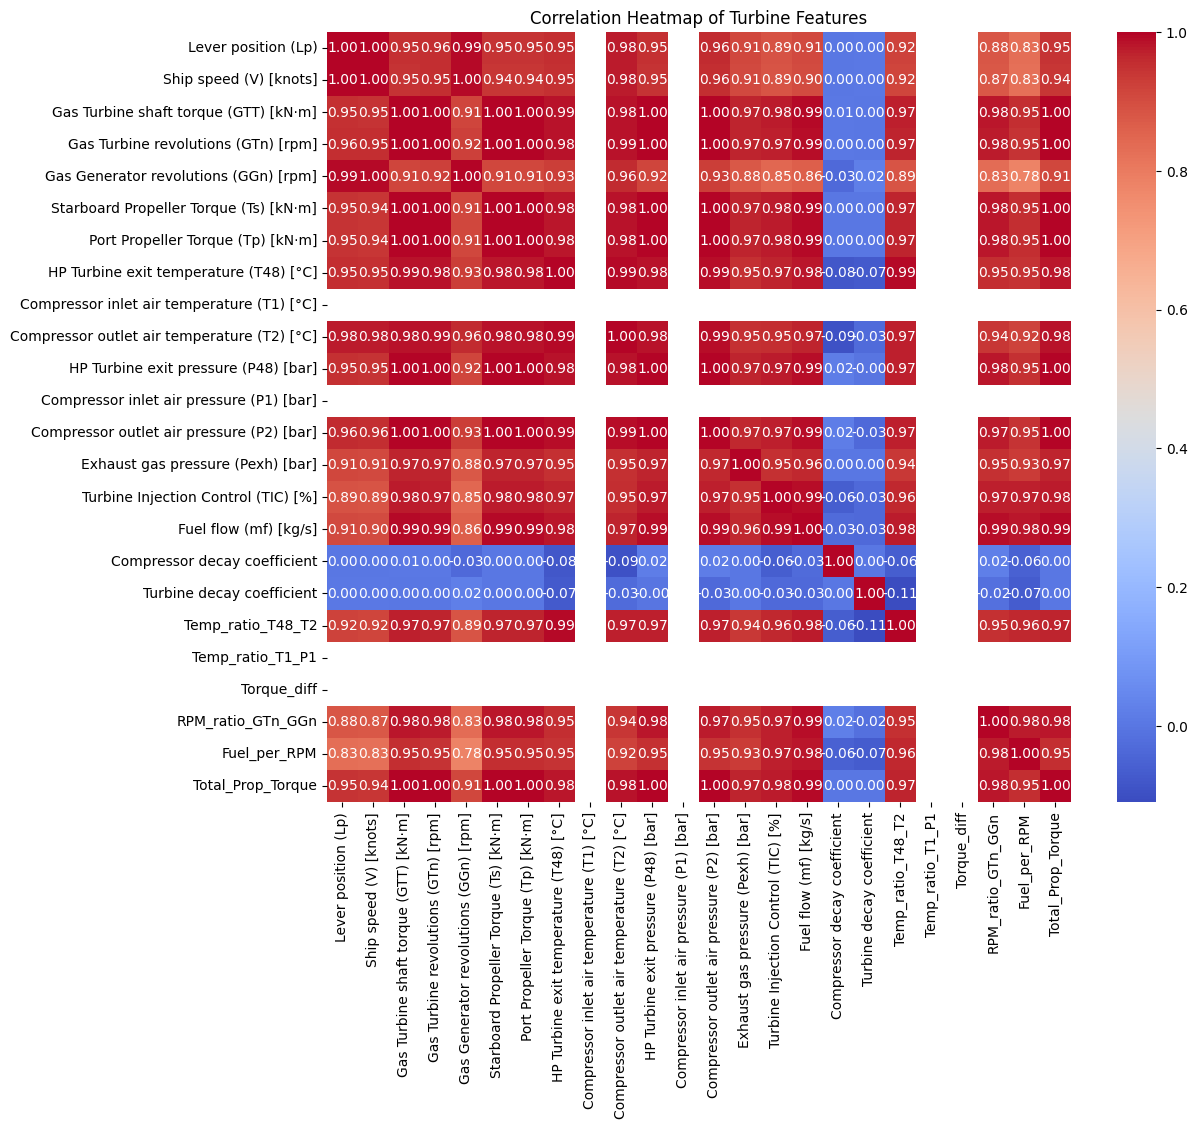

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Turbine Features")
plt.show()

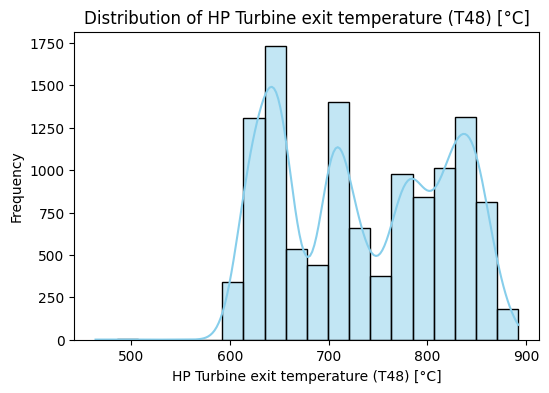

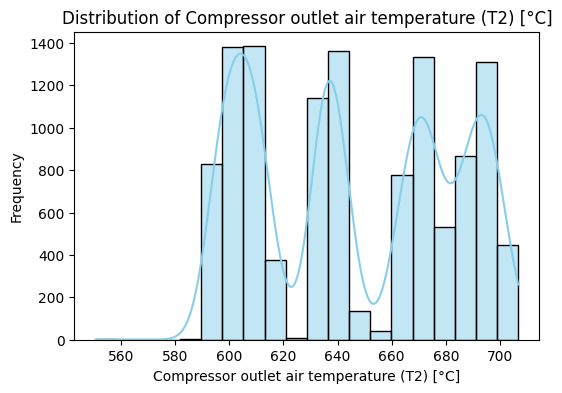

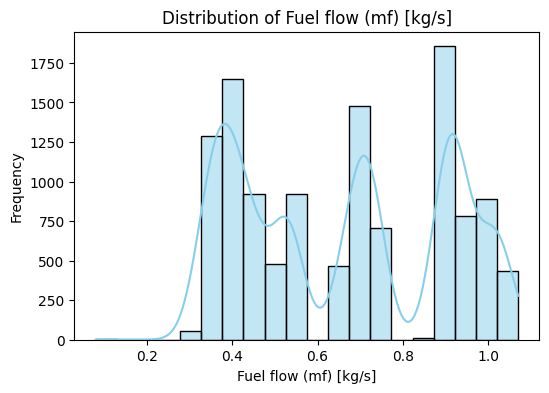

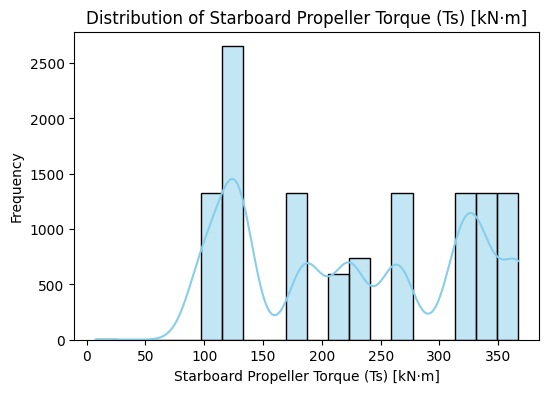

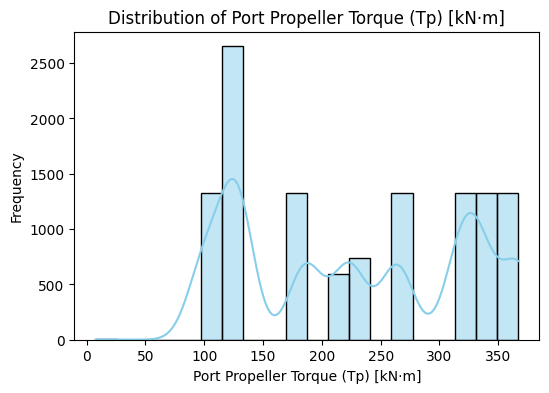

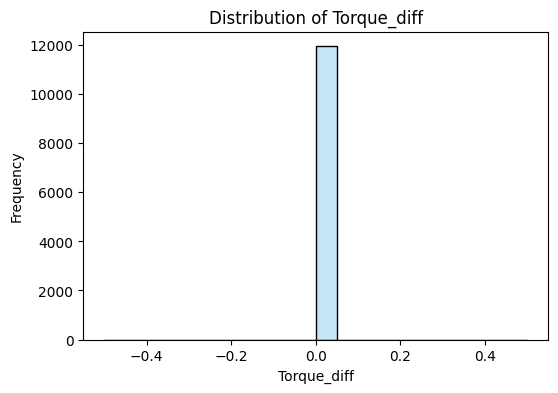

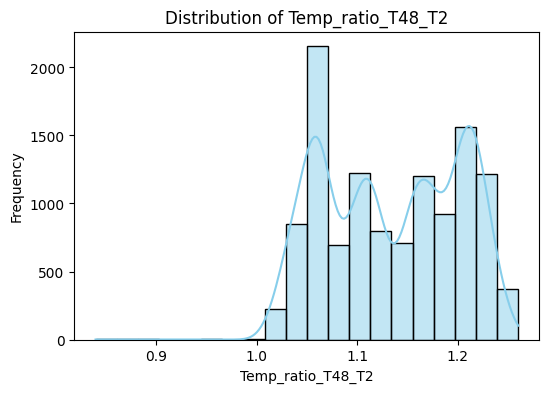

In [42]:
#Distributions of Key Columns
key_cols = ['HP Turbine exit temperature (T48) [°C]',
            'Compressor outlet air temperature (T2) [°C]',
            'Fuel flow (mf) [kg/s]',
            'Starboard Propeller Torque (Ts) [kN·m]',
            'Port Propeller Torque (Tp) [kN·m]',
            'Torque_diff',
            'Temp_ratio_T48_T2']

for col in key_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


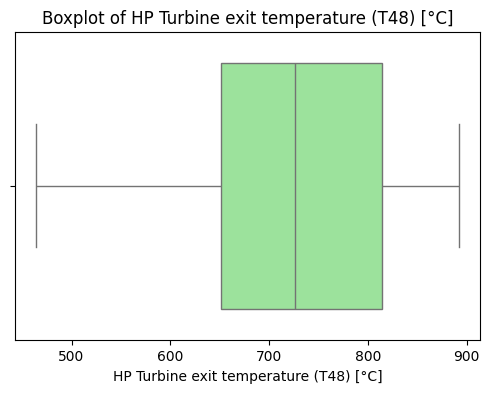

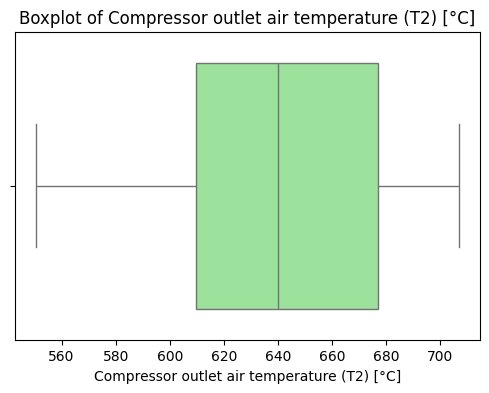

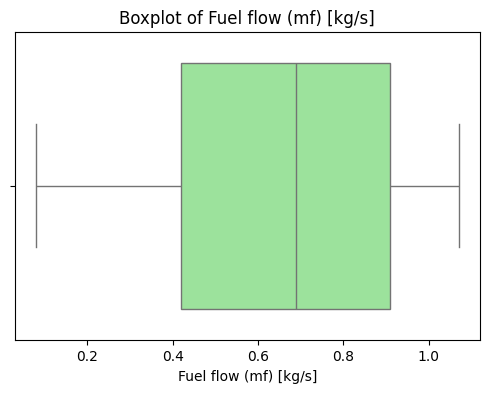

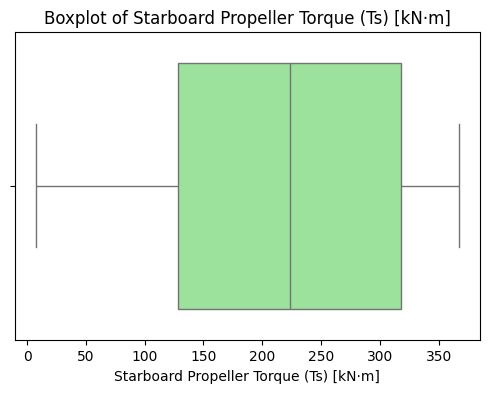

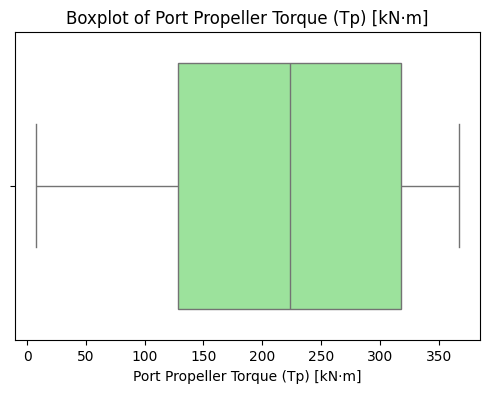

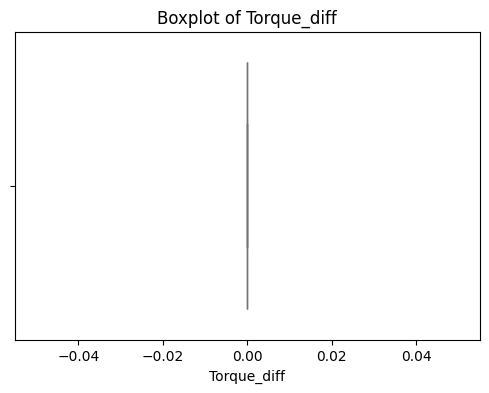

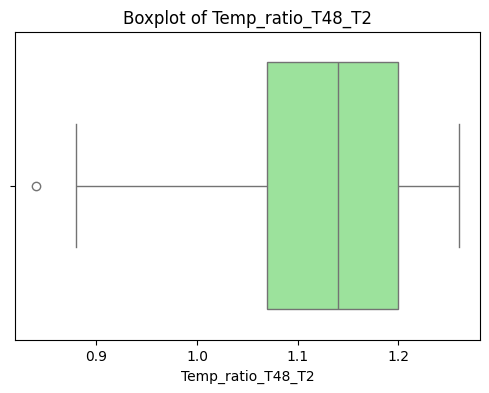

In [43]:
#Boxplots to detect remaining outliers
for col in key_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.show()

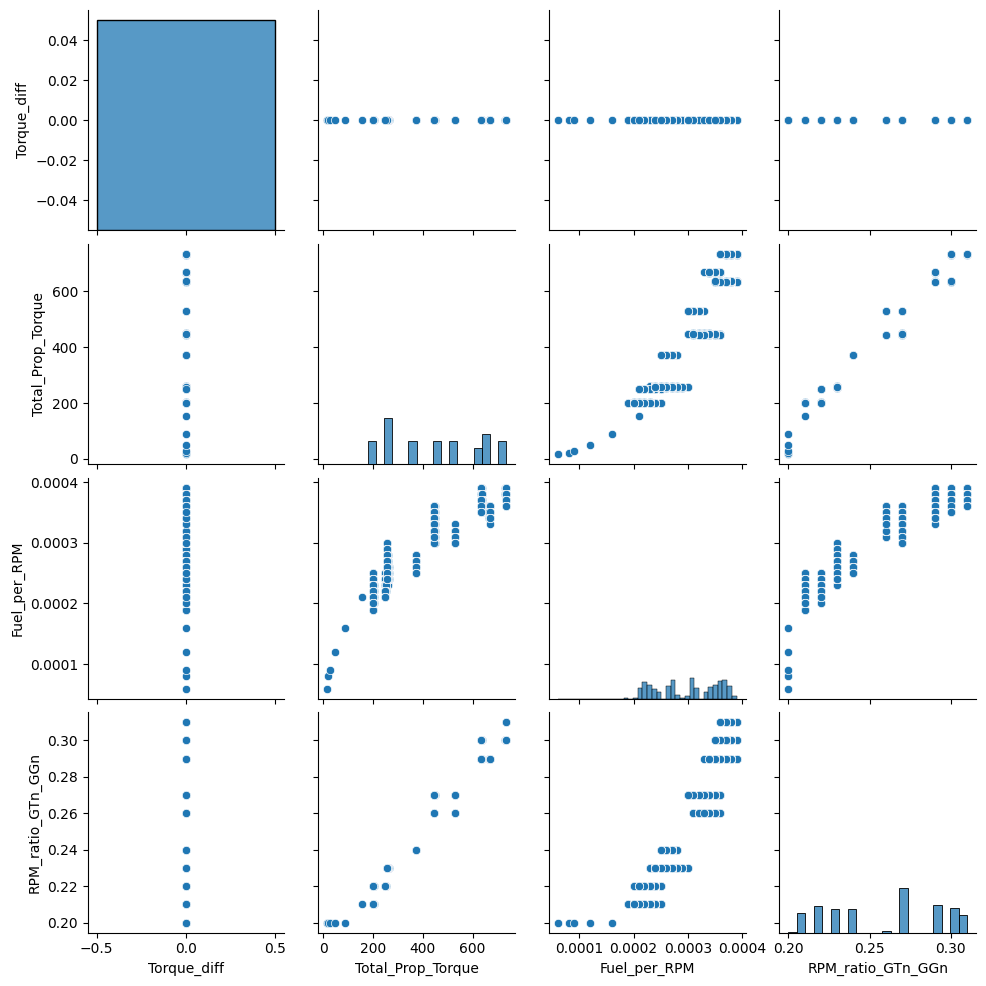

In [44]:
#Pairwise relationship
sns.pairplot(df[['Torque_diff', 'Total_Prop_Torque', 'Fuel_per_RPM', 'RPM_ratio_GTn_GGn']])
plt.show()

In [48]:
# Save df as cleaned csv
numeric_cols = df.columns[1:]  # exclude index
df[numeric_cols] = df[numeric_cols].round(2)

# Save to CSV again
df.to_csv("turbine_data_cleaned.csv", index=False)
print("turbine_data_cleaned.csv created successfully")

turbine_data_cleaned.csv created successfully
